#### Faulty Netlist to Graph generation

In [1]:
# build_csv_with_fault_topology.py
"""
Create nodes.csv and edges.csv but this time we EMBED the injected faults into the graph:
 - Stuck-at: create pseudo source node SA0_<net> / SA1_<net> that overrides driver(net)
 - Bridging: create pseudo node BR_<n1>_<n2>, add it as driver(n1), and connect driver(n2) -> BR node
 - Glitch:   create pseudo source node GL_<net> (stores delays as attributes), overrides driver(net)

Labels:
 - label=1 only for the pseudo fault node we create; others 0.

This produces structural differences so SCOAP, degrees, and distances will reflect the faults.
"""

import re
import csv
from pathlib import Path
from collections import defaultdict

SRC_DIR    = Path("verilog_benchmark_circuits")   # clean originals
FAULT_DIRS = {"stuck_at": Path("stuck_at"),
              "glitch"  : Path("glitch"),
              "bridging": Path("bridging")}
OUT_NODE   = Path("nodes.csv")
OUT_EDGE   = Path("edges.csv")

# ---------- regex ----------
COMMENT_RE    = re.compile(r'//.*')
MODULE_RE     = re.compile(r'\bmodule\b.*?\bendmodule\b', re.DOTALL)
PORT_DECL_RE  = re.compile(r'\b(input|output)\b\s+([^;]+);')
NET_DECL_RE   = re.compile(r'\b(wire|reg)\b\s+([^;]+);')
INST_RE       = re.compile(r'^\s*([A-Za-z_]\w*)\s+([A-Za-z_]\w*)\s*\(\s*(.*?)\s*\)\s*$', re.DOTALL)
PORT_MAP_RE   = re.compile(r'\.(\w+)\s*\(\s*([\w\[\]\\]+)\s*\)')
ID_RE         = re.compile(r'(\\[^\s]+\s|[A-Za-z_]\w*)')
OUT_PORTS     = {"Y","ZN","Z","Q","O","CO","S","SUM"}

# fault regex
ASSIGN_CONST_RE = re.compile(r'assign\s+([\w\[\]\\]+)\s*=\s*1\'b([01])\s*;', re.IGNORECASE)
ASSIGN_BRIDGE_RE = re.compile(r'assign\s+([\w\[\]\\]+)\s*=\s*([\w\[\]\\]+)\s*;', re.IGNORECASE)
GLITCH_BLOCK_RE = re.compile(r'initial\s*begin(.*?)end', re.IGNORECASE | re.DOTALL)
GLITCH_TOGGLE_RE = re.compile(r'#\s*(\d+)\s+([\w\[\]\\]+)\s*=\s*~\s*\2\s*;')

def strip_comments(txt: str) -> str:
    return COMMENT_RE.sub("", txt)

def extract_module(txt: str) -> str:
    m = MODULE_RE.search(txt)
    return m.group(0) if m else ""

def find_ids(s: str):
    return [m.group(1).rstrip() for m in ID_RE.finditer(s)]

def parse_named_ports(s: str):
    return {m.group(1): m.group(2).rstrip() for m in PORT_MAP_RE.finditer(s)}

def parse_instances(body: str):
    """Return gates, driver, loads from instance connections only (no assigns)."""
    gates  = {}             # inst -> gate_type
    driver = {}             # net -> inst (output driver)
    loads  = defaultdict(list)  # net -> [insts that read the net]

    tmp = re.sub(r'\((.*?)\)', lambda x: x.group(0).replace('\n',' '), body, flags=re.DOTALL)
    for stmt in tmp.split(';'):
        stmt = stmt.strip()
        if not stmt or "(" not in stmt:
            continue
        head = stmt.split()[0]
        if head in {"module","endmodule","input","output","wire","reg","assign"}:
            continue
        m = INST_RE.match(stmt)
        if not m:
            continue
        gatetype, inst, ports_str = m.groups()
        gates[inst] = gatetype
        if "." in ports_str:
            pm = parse_named_ports(ports_str)
            for p, net in pm.items():
                if p in OUT_PORTS:
                    driver[net] = inst
                else:
                    loads[net].append(inst)
        else:
            tokens = find_ids(ports_str)
            if not tokens:
                continue
            out, ins = tokens[0], tokens[1:]
            driver[out] = inst
            for net in ins:
                loads[net].append(inst)
    return gates, driver, loads

def inject_fault_topology(raw_text: str, ftype: str, gates, driver, loads):
    """
    Mutate (gates, driver, loads) in-place to reflect injected faults.
    We only touch the nets actually mentioned in injected code.
    Returns: list of created pseudo nodes and (optional) per-node attrs dict.
    """
    created_nodes = []
    node_attrs = {}   # name -> dict of attributes (e.g., glitch delays)

    if ftype == "clean":
        return created_nodes, node_attrs

    # We only need to scan the file tail where injection is appended.
    # But to be robust, scan entire text.
    text = raw_text

    # --- stuck-at: assign <net> = 1'b0/1'b1;
    for m in ASSIGN_CONST_RE.finditer(text):
        net = m.group(1)
        val = m.group(2)
        inst = f"SA{val}_{net}"
        gates[inst] = f"sa{val}"  # gate_type
        # override driver(net) with pseudo source
        driver[net] = inst
        # SA node is a pure source; no inputs; its outputs will be wired when edges are created
        created_nodes.append(inst)

    # --- glitch: look for two toggles inside an initial block
    # We create GL_<net> and override driver(net) = GL_<net>
    for blk in GLITCH_BLOCK_RE.finditer(text):
        body = blk.group(1)
        toggles = GLITCH_TOGGLE_RE.findall(body)
        # group by net
        by_net = {}
        for delay, net in toggles:
            by_net.setdefault(net, []).append(int(delay))
        for net, delays in by_net.items():
            if len(delays) >= 1:
                inst = f"GL_{net}"
                gates[inst] = "glitch"
                driver[net] = inst
                created_nodes.append(inst)
                node_attrs[inst] = {"glitch_delays": sorted(delays)}

    # --- bridging: assign n1 = n2; but avoid picking up stuck-at lines (they match too); so filter constants.
    for m in ASSIGN_BRIDGE_RE.finditer(text):
        n1, n2 = m.group(1), m.group(2)
        # skip if RHS is a constant  (handled by stuck-at)
        if re.match(r"1'b[01]$", n2, flags=re.IGNORECASE):
            continue
        # create BR node: input from n2, output drives n1
        inst = f"BR_{n1}_{n2}"
        gates[inst] = "bridge"
        # 1) connect driver(n2) -> BR node by adding BR as a *load* of net n2
        loads[n2].append(inst)
        # 2) BR becomes the driver of n1 (override)
        driver[n1] = inst
        created_nodes.append(inst)

    return created_nodes, node_attrs

def write_graph_csv(netfile: str, ftype: str, raw_text: str, node_w, edge_w):
    # strip comments & isolate module body
    body = extract_module(strip_comments(raw_text))
    if not body:
        return False

    # IO directions to generate PI/PO nodes (optional; we keep gates only here)
    # (Well keep the node set to instances & pseudo nodes; PIs/POs are implicit via zero in/out degrees)
    gates, driver, loads = parse_instances(body)

    # Apply topology edits for injected faults
    created_nodes, node_attrs = inject_fault_topology(raw_text, ftype, gates, driver, loads)

    # Build node set: all instances + pseudo nodes + any loads-only instances we added
    node_set = set(gates.keys())
    # ensure loads-only pseudo nodes are present (e.g., BR)
    for net, dsts in loads.items():
        for inst in dsts:
            if inst not in gates:
                # mark as special if somehow missed
                gates[inst] = "bridge"
                node_set.add(inst)

    # Degrees (compute after connections are defined)
    indeg = {n: 0 for n in node_set}
    outdeg = {n: 0 for n in node_set}

    # For each net, we will write edges: src = driver[net] -> dst in loads[net]
    # Accumulate edges first to count degrees
    edges = []
    for net, src_inst in list(driver.items()):
        dsts = loads.get(net, [])
        for d in dsts:
            if src_inst in node_set and d in node_set:
                edges.append((src_inst, d))
                outdeg[src_inst] += 1
                indeg[d] += 1

    # Labels: only pseudo fault nodes are label=1
    labels = {n: 0 for n in node_set}
    for n in created_nodes:
        labels[n] = 1

    # Write nodes
    # We keep minimal structural columns here; enhanced metrics are computed later by feature_engineer.py
    node_cols = [
        "netlist_file","fault_type","node_id","gate_type",
        "in_degree","out_degree","total_degree",
        "path_depth","CC0","CC1","CO",
        "is_input","is_output","label"
    ]
    # dummy placeholders for path_depth/CC/CO/is_input/is_output (feature_engineer will recompute)
    for n in sorted(node_set):
        node_w.writerow([
            netfile, ftype, n, gates.get(n,"unk"),
            indeg[n], outdeg[n], indeg[n] + outdeg[n],
            0, "", "", "",
            0, 0, labels[n]
        ])

    # fanout per source instance (simple count)
    fanout = defaultdict(int)
    for s, d in edges:
        fanout[s] += 1

    # Write edges
    for s, d in edges:
        edge_w.writerow([netfile, ftype, s, d, fanout[s]])

    return True

def main():
    # reset outputs
    if OUT_NODE.exists(): OUT_NODE.unlink()
    if OUT_EDGE.exists(): OUT_EDGE.unlink()

    with OUT_NODE.open("w", newline="") as nf, OUT_EDGE.open("w", newline="") as ef:
        node_w = csv.writer(nf); edge_w = csv.writer(ef)
        node_w.writerow([
            "netlist_file","fault_type","node_id","gate_type",
            "in_degree","out_degree","total_degree",
            "path_depth","CC0","CC1","CO",
            "is_input","is_output","label"
        ])
        edge_w.writerow(["netlist_file","fault_type","src_node","dst_node","fan_out"])

        # clean originals
        for v in sorted(SRC_DIR.glob("*.v")):
            txt = v.read_text()
            write_graph_csv(v.name, "clean", txt, node_w, edge_w)

        # fault directories
        for ftype, folder in FAULT_DIRS.items():
            if not folder.exists(): 
                continue
            for v in sorted(folder.glob("*.v")):
                txt = v.read_text()
                # strip the leading "ftype_" in filename to keep netlist base aligned
                base = v.name
                prefix = f"{ftype}_"
                if base.startswith(prefix):
                    base = base[len(prefix):]
                write_graph_csv(base, ftype, txt, node_w, edge_w)

    print(f"? Wrote {OUT_NODE} and {OUT_EDGE} with fault-aware topology.")

if __name__ == "__main__":
    main()


? Wrote nodes.csv and edges.csv with fault-aware topology.


#### Generating enhanced nodes and edges csv files from nodes.csv and edges.csv

In [6]:
# feature_engineer.py
"""
Compute enhanced node/edge features from fault-aware nodes.csv / edges.csv:
 - Exact SCOAP CC0 / CC1 / CO (combinational)
 - path_depth (from sources / indegree==0)
 - dist_to_PO (reverse BFS from sinks / outdegree==0)
 - fanout and fanout_norm (per graph)
 - gate_delay (including pseudo gates: sa0/sa1/bridge/glitch)

Inputs:
    nodes.csv  (from build_csv_with_fault_topology.py)
    edges.csv  (same)
Outputs:
    nodes_enhanced.csv
    edges_enhanced.csv
"""

from pathlib import Path
from collections import defaultdict, deque
import math
import csv

import pandas as pd
import numpy as np

# -------- config --------
NODES_CSV = Path("nodes.csv")
EDGES_CSV = Path("edges.csv")
OUT_NODES = Path("nodes_enhanced.csv")
OUT_EDGES = Path("edges_enhanced.csv")

# Gate delays (adjust as needed; pseudo gates included)
GATE_DELAY = {
    "and": 1.0, "nand": 1.0, "or": 1.0, "nor": 1.0,
    "not": 0.5, "inv": 0.5, "buf": 0.5, "buff": 0.5,
    "xor": 2.0, "xnor": 2.0,
    "pi": 0.0, "po": 0.0, "PI": 0.0, "PO": 0.0,
    # pseudo fault sources / elements
    "sa0": 0.0, "sa1": 0.0,         # constants
    "bridge": 0.2,                   # pass-through
    "glitch": 0.2,                   # small source (no fixed timing here)
    "unk": 1.0
}

INF = 10**9

# -------- SCOAP helpers --------
def scoap_cc_for_gate(gtype: str, in_cc0, in_cc1):
    """
    SCOAP controllability (exact for common gates).
    Returns (CC0_out, CC1_out).
    """
    gt = (gtype or "").lower()
    a0 = list(in_cc0)
    a1 = list(in_cc1)

    # Pseudo sources
    if gt == "sa0":
        return 1, INF
    if gt == "sa1":
        return INF, 1
    if gt in ("glitch",):
        # treat as primary source if no inputs; else buffer-like
        if len(a0) == 0:
            return 1, 1
        return 1 + a0[0], 1 + a1[0]
    if gt in ("bridge", "buf", "buff"):
        if len(a0) == 0:
            return 1, 1
        return 1 + a0[0], 1 + a1[0]

    # Inverters/buffers
    if gt in ("not", "inv"):
        if len(a0) == 0:
            return 1, 1
        return 1 + a1[0], 1 + a0[0]

    if gt in ("and",):
        cc0 = 1 + (min(a0) if a0 else 0)
        cc1 = 1 + sum(a1)
        return cc0, cc1

    if gt in ("or",):
        cc0 = 1 + sum(a0)
        cc1 = 1 + (min(a1) if a1 else 0)
        return cc0, cc1

    if gt in ("nand",):
        cc0 = 1 + sum(a1)                 # to drive 0 at NAND out, inputs must be 1
        cc1 = 1 + (min(a0) if a0 else 0)
        return cc0, cc1

    if gt in ("nor",):
        cc0 = 1 + (min(a1) if a1 else 0)
        cc1 = 1 + sum(a0)
        return cc0, cc1

    if gt in ("xor",):
        if len(a0) == 2:
            cc0 = 1 + min(a0[0] + a0[1], a1[0] + a1[1])
            cc1 = 1 + min(a1[0] + a0[1], a0[0] + a1[1])
        else:
            # approximate for >2 inputs
            cc0 = 1 + min(sum(a0), sum(a1))
            cc1 = 1 + min(sum(a0), sum(a1))
        return cc0, cc1

    if gt in ("xnor",):
        if len(a0) == 2:
            cc0 = 1 + min(a1[0] + a0[1], a0[0] + a1[1])
            cc1 = 1 + min(a0[0] + a0[1], a1[0] + a1[1])
        else:
            cc0 = 1 + min(sum(a0), sum(a1))
            cc1 = 1 + min(sum(a0), sum(a1))
        return cc0, cc1

    # Fallback: AND-like conservative
    cc0 = 1 + (min(a0) if a0 else 0)
    cc1 = 1 + sum(a1)
    return cc0, cc1


def scoap_co_for_gate_input(gtype: str, out_co: int, other_cc0, other_cc1):
    """
    Observability for a gate input:
      CO(in_i) = out_co + 1 + sum(CC_noncontrolling(other inputs))
    """
    gt = (gtype or "").lower()

    if gt in ("buf", "buff", "not", "inv", "bridge", "glitch", "sa0", "sa1"):
        # One input (or source): just pass-through cost
        return int(math.ceil(out_co + 1))

    if gt in ("and", "nand"):
        extra = sum(other_cc1)  # non-controlling value = 1
        return int(math.ceil(out_co + 1 + extra))

    if gt in ("or", "nor"):
        extra = sum(other_cc0)  # non-controlling value = 0
        return int(math.ceil(out_co + 1 + extra))

    if gt in ("xor", "xnor"):
        # need specific pattern on other inputs; use min(CC0, CC1)
        extra = sum(min(a, b) for a, b in zip(other_cc0, other_cc1))
        return int(math.ceil(out_co + 1 + extra))

    # Fallback
    extra = sum(min(a, b) for a, b in zip(other_cc0, other_cc1))
    return int(math.ceil(out_co + 1 + extra))


# -------- main pipeline --------
def build_struct(nodes_df, edges_df):
    """
    Build per-(netlist_file, fault_type) adjacency and metadata.
    """
    graphs = {}
    for (nf, ft), gnodes in nodes_df.groupby(["netlist_file", "fault_type"], sort=False):
        node_ids = gnodes["node_id"].tolist()
        gate_type = dict(zip(gnodes["node_id"], gnodes["gate_type"]))
        label_map = dict(zip(gnodes["node_id"], gnodes["label"]))

        sube = edges_df[(edges_df["netlist_file"] == nf) & (edges_df["fault_type"] == ft)]
        succ = defaultdict(list)
        pred = defaultdict(list)
        for _, row in sube.iterrows():
            s = row["src_node"]; d = row["dst_node"]
            if s in gate_type and d in gate_type:
                succ[s].append(d)
                pred[d].append(s)

        # in/out degrees from adjacency
        indeg = {n: len(pred[n]) for n in node_ids}
        outdeg = {n: len(succ[n]) for n in node_ids}
        fanout = {n: len(succ[n]) for n in node_ids}

        graphs[(nf, ft)] = {
            "nodes": node_ids,
            "gate_type": gate_type,
            "label": label_map,
            "succ": succ,
            "pred": pred,
            "indeg": indeg,
            "outdeg": outdeg,
            "fanout": fanout
        }
    return graphs


def compute_topology_features(meta):
    nodes = meta["nodes"]; succ = meta["succ"]; pred = meta["pred"]

    # Sources (act like PIs): indegree==0
    sources = [n for n in nodes if len(pred[n]) == 0]
    # Sinks (act like POs): outdegree==0
    sinks = [n for n in nodes if len(succ[n]) == 0]

    # path_depth from sources
    path_depth = {n: 0 for n in sources}
    dq = deque(sources)
    while dq:
        u = dq.popleft()
        for v in succ[u]:
            if v not in path_depth:
                path_depth[v] = path_depth[u] + 1
                dq.append(v)
    if path_depth:
        maxd = max(path_depth.values())
    else:
        maxd = 0
    for n in nodes:
        path_depth.setdefault(n, maxd)

    # dist_to_PO by reverse BFS from sinks
    dist_po = {n: 0 for n in sinks}
    dq = deque(sinks)
    while dq:
        u = dq.popleft()
        for v in pred[u]:
            if v not in dist_po:
                dist_po[v] = dist_po[u] + 1
                dq.append(v)
    if dist_po:
        maxdpo = max(dist_po.values())
    else:
        maxdpo = 0
    for n in nodes:
        dist_po.setdefault(n, maxdpo)

    return sources, sinks, path_depth, dist_po


def compute_scoap(meta, sources):
    nodes = meta["nodes"]; succ = meta["succ"]; pred = meta["pred"]; gate_type = meta["gate_type"]

    # Kahn topological order (best-effort; if cycles exist, fall back to node order)
    indeg_tmp = {n: len(pred[n]) for n in nodes}
    q = deque([n for n in nodes if indeg_tmp[n] == 0])
    topo = []
    while q:
        u = q.popleft()
        topo.append(u)
        for v in succ[u]:
            indeg_tmp[v] -= 1
            if indeg_tmp[v] == 0:
                q.append(v)
    if len(topo) != len(nodes):
        topo = list(nodes)  # fallback if not DAG

    # Forward: CC0/CC1
    cc0 = {n: INF for n in nodes}
    cc1 = {n: INF for n in nodes}
    for p in sources:
        # sources (including sa0/sa1/glitch with indeg==0) behave like PI for baseline
        gt = (gate_type.get(p, "") or "").lower()
        if gt == "sa0":
            cc0[p], cc1[p] = 1, INF
        elif gt == "sa1":
            cc0[p], cc1[p] = INF, 1
        else:
            # glitch/bridge with no inputs are treated as generic source
            cc0[p], cc1[p] = 1, 1

    for n in topo:
        ins = pred[n]
        in_cc0 = [cc0[i] for i in ins]
        in_cc1 = [cc1[i] for i in ins]
        c0, c1 = scoap_cc_for_gate(gate_type.get(n, "unk"), in_cc0, in_cc1)
        # combine with existing (min to be safe if multiple passes)
        cc0[n] = min(cc0[n], c0)
        cc1[n] = min(cc1[n], c1)

    # Backward: CO
    co = {n: INF for n in nodes}
    # Initialize sinks (PO-like) to 0
    sinks = [n for n in nodes if len(succ[n]) == 0]
    for s in sinks:
        co[s] = 0

    # Iterate backwards to propagate CO
    changed = True
    iters = 0
    while changed and iters < 100:
        changed = False
        iters += 1

        # update inputs of each gate from its output CO
        for g in reversed(topo):
            out_co = co[g]
            inputs = pred[g]
            if not inputs:
                continue
            for i_idx, i in enumerate(inputs):
                others = [x for x in inputs if x != i]
                other_cc0 = [cc0[x] for x in others]
                other_cc1 = [cc1[x] for x in others]
                cand = scoap_co_for_gate_input(gate_type.get(g, "unk"), out_co, other_cc0, other_cc1)
                if cand < co[i]:
                    co[i] = cand
                    changed = True

        # also along fanouts: a nodes CO is min(child CO)+1
        for n in nodes:
            if succ[n]:
                best = min(co[ch] for ch in succ[n]) + 1
                if best < co[n]:
                    co[n] = best
                    changed = True

    # sanitize
    for n in nodes:
        if cc0[n] >= INF: cc0[n] = int(1e6)
        if cc1[n] >= INF: cc1[n] = int(1e6)
        if co[n]  >= INF: co[n]  = int(1e6)

    return cc0, cc1, co


def main():
    if not NODES_CSV.exists() or not EDGES_CSV.exists():
        raise SystemExit("nodes.csv or edges.csv not found. Run build_csv_with_fault_topology.py first.")

    nodes_df = pd.read_csv(NODES_CSV)
    edges_df = pd.read_csv(EDGES_CSV)

    # Prepare writers
    if OUT_NODES.exists(): OUT_NODES.unlink()
    if OUT_EDGES.exists(): OUT_EDGES.unlink()

    node_cols = [
        "netlist_file","fault_type","node_id","gate_type",
        "in_degree","out_degree","total_degree",
        "path_depth",
        "CC0_approx","CC1_approx","CO_approx",   # keep columns for compatibility (left blank)
        "CC0_exact","CC1_exact","CO_exact",
        "dist_to_PO",
        "fanout","fanout_norm","gate_delay",
        "label"
    ]

    with OUT_NODES.open("w", newline="") as nf, OUT_EDGES.open("w", newline="") as ef:
        node_w = csv.writer(nf); edge_w = csv.writer(ef)
        node_w.writerow(node_cols)
        edge_w.writerow(["netlist_file","fault_type","src_node","dst_node","fan_out"])

        # Process per graph (netlist_file, fault_type)
        graphs = build_struct(nodes_df, edges_df)

        for (nf, ft), meta in graphs.items():
            nodes = meta["nodes"]; succ = meta["succ"]; pred = meta["pred"]
            indeg = meta["indeg"]; outdeg = meta["outdeg"]; fanout = meta["fanout"]
            gate_type = meta["gate_type"]; labels = meta["label"]

            # topology features
            sources, sinks, path_depth, dist_po = compute_topology_features(meta)

            # SCOAP
            cc0, cc1, co = compute_scoap(meta, sources)

            # fanout normalization within graph
            max_fout = max(fanout.values()) if fanout else 1.0
            if max_fout <= 0: max_fout = 1.0

            # write nodes
            for n in nodes:
                gt = (gate_type.get(n, "unk") or "unk")
                gd = GATE_DELAY.get(gt.lower(), GATE_DELAY["unk"])
                node_w.writerow([
                    nf, ft, n, gt,
                    indeg[n], outdeg[n], indeg[n] + outdeg[n],
                    path_depth[n],
                    "", "", "",                      # approx left blank
                    int(cc0[n]), int(cc1[n]), int(co[n]),
                    dist_po[n],
                    fanout[n], float(fanout[n]) / float(max_fout), gd,
                    int(labels.get(n, 0))
                ])

            # write edges with per-source fanout
            for s in nodes:
                for d in succ[s]:
                    edge_w.writerow([nf, ft, s, d, fanout[s]])

    print(f"? Wrote enhanced nodes -> {OUT_NODES} and edges -> {OUT_EDGES}")


if __name__ == "__main__":
    main()


? Wrote enhanced nodes -> nodes_enhanced.csv and edges -> edges_enhanced.csv


#### Feature Analysis

In [4]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

results = []

# Identify numeric columns (exclude non-numeric columns like 'fault_type')
numeric_features = nodes_df.select_dtypes(include=[np.number]).columns.tolist()

for fault in ["stuck_at", "glitch", "bridging"]:
    for feat in numeric_features:
        clean_vals = nodes_df.loc[nodes_df["fault_type"]=="clean", feat].dropna()
        fault_vals = nodes_df.loc[nodes_df["fault_type"]==fault, feat].dropna()
        
        if len(fault_vals) == 0 or len(clean_vals) == 0:
            continue  # skip if data missing
        
        # Cohen's d
        pooled_std = np.sqrt(((clean_vals.std()**2) + (fault_vals.std()**2)) / 2)
        if pooled_std == 0:
            d = 0
        else:
            d = (fault_vals.mean() - clean_vals.mean()) / pooled_std
        
        # AUROC
        subset = nodes_df[nodes_df["fault_type"].isin(["clean", fault])].copy()
        y_true = (subset["fault_type"]==fault).astype(int)
        y_score = subset[feat].fillna(0)
        
        auc = roc_auc_score(y_true, y_score)
        
        results.append((fault, feat, d, auc))

# Show results
res_df = pd.DataFrame(results, columns=["FaultType", "Feature", "Cohen_d", "AUROC"])
print(res_df.sort_values(["FaultType","AUROC"], ascending=[True,False]))


   FaultType       Feature   Cohen_d     AUROC
29  bridging     CC1_exact  0.090543  0.675457
28  bridging     CC0_exact  0.088848  0.667618
35  bridging         label  0.114133  0.503235
27  bridging    path_depth -0.019729  0.499927
25  bridging    out_degree -0.001054  0.498879
32  bridging        fanout -0.001054  0.498879
24  bridging     in_degree -0.005720  0.498506
26  bridging  total_degree -0.002088  0.498331
34  bridging    gate_delay -0.015092  0.496765
33  bridging   fanout_norm -0.033231  0.495890
31  bridging    dist_to_PO -0.874607  0.281212
30  bridging      CO_exact -0.800143  0.281201
23    glitch         label  0.114133  0.503235
12    glitch     in_degree -0.014058  0.497098
13    glitch    out_degree -0.002607  0.496981
20    glitch        fanout -0.002607  0.496981
22    glitch    gate_delay -0.015092  0.496765
21    glitch   fanout_norm -0.029496  0.496652
14    glitch  total_degree -0.005165  0.495700
15    glitch    path_depth -0.114673  0.479473
16    glitch 

In [7]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

results = []
nodes_df = pd.read_csv("nodes_enhanced.csv")
edges_df = pd.read_csv("edges_enhanced.csv")

# Identify numeric columns (exclude non-numeric columns like 'fault_type')
numeric_features = nodes_df.select_dtypes(include=[np.number]).columns.tolist()

for fault in ["stuck_at", "glitch", "bridging"]:
    for feat in numeric_features:
        clean_vals = nodes_df.loc[nodes_df["fault_type"]=="clean", feat].dropna()
        fault_vals = nodes_df.loc[nodes_df["fault_type"]==fault, feat].dropna()
        
        if len(fault_vals) == 0 or len(clean_vals) == 0:
            continue  # skip if data missing
        
        # Cohen's d
        pooled_std = np.sqrt(((clean_vals.std()**2) + (fault_vals.std()**2)) / 2)
        if pooled_std == 0:
            d = 0
        else:
            d = (fault_vals.mean() - clean_vals.mean()) / pooled_std
        
        # AUROC
        subset = nodes_df[nodes_df["fault_type"].isin(["clean", fault])].copy()
        y_true = (subset["fault_type"]==fault).astype(int)
        y_score = subset[feat].fillna(0)
        
        auc = roc_auc_score(y_true, y_score)
        
        results.append((fault, feat, d, auc))

# Show results
res_df = pd.DataFrame(results, columns=["FaultType", "Feature", "Cohen_d", "AUROC"])
print(res_df.sort_values(["FaultType","AUROC"], ascending=[True,False]))


   FaultType       Feature   Cohen_d     AUROC
29  bridging     CC1_exact  0.090543  0.675457
28  bridging     CC0_exact  0.088848  0.667618
35  bridging         label  0.114133  0.503235
27  bridging    path_depth -0.019729  0.499927
25  bridging    out_degree -0.001054  0.498879
32  bridging        fanout -0.001054  0.498879
24  bridging     in_degree -0.005720  0.498506
26  bridging  total_degree -0.002088  0.498331
34  bridging    gate_delay -0.015092  0.496765
33  bridging   fanout_norm -0.033231  0.495890
31  bridging    dist_to_PO -0.874607  0.281212
30  bridging      CO_exact -0.800143  0.281201
23    glitch         label  0.114133  0.503235
12    glitch     in_degree -0.014058  0.497098
13    glitch    out_degree -0.002607  0.496981
20    glitch        fanout -0.002607  0.496981
22    glitch    gate_delay -0.015092  0.496765
21    glitch   fanout_norm -0.029496  0.496652
14    glitch  total_degree -0.005165  0.495700
15    glitch    path_depth -0.114673  0.479473
16    glitch 

#### Training 

In [6]:
# train_GAT.py
import torch
import torch.nn as nn
import torch.nn.functional as F
#import torch_geometric
from torch_geometric.nn import SAGEConv, GCNConv, GlobalAttention
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import pandas as pd
import pickle
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import numpy as np

# ------------------------------
# Config
# ------------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"
MODEL_FILE = "model_GAT.pkl"
BATCH_SIZE = 1
EPOCHS = 30
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Dataset loading
# ------------------------------
def load_graphs(nodes_file, edges_file):
    nodes_df = pd.read_csv(nodes_file)
    edges_df = pd.read_csv(edges_file)

    label_enc = LabelEncoder()
    nodes_df["fault_label"] = label_enc.fit_transform(nodes_df["fault_type"])
    class_names = list(label_enc.classes_)

    graphs = []
    for (nf, ft), group_nodes in nodes_df.groupby(["netlist_file", "fault_type"]):
        sub_edges = edges_df[(edges_df["netlist_file"] == nf) &
                             (edges_df["fault_type"] == ft)]

        x_feats = group_nodes[
            ["in_degree", "out_degree", "total_degree",
             "path_depth",
             "CC0_exact", "CC1_exact", "CO_exact",
             "dist_to_PO",
             "fanout", "fanout_norm",
             "gate_delay"]
        ].values.astype(np.float32)

        y_labels = group_nodes["fault_label"].values.astype(np.int64)

        node_id_map = {nid: idx for idx, nid in enumerate(group_nodes["node_id"])}

        edge_index = []
        for _, row in sub_edges.iterrows():
            if row["src_node"] in node_id_map and row["dst_node"] in node_id_map:
                edge_index.append([node_id_map[row["src_node"]],
                                   node_id_map[row["dst_node"]]])
        if edge_index:
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)

        data = Data(
            x=torch.tensor(x_feats, dtype=torch.float32),
            edge_index=edge_index,
            y=torch.tensor(y_labels, dtype=torch.long)
        )
        graphs.append(data)

    return graphs, class_names

# ------------------------------
# Model
# ------------------------------
class HybridGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes):
        super().__init__()
        self.sage1 = SAGEConv(in_channels, hidden_channels)
        self.gcn1 = GCNConv(hidden_channels, hidden_channels)
        self.attn_pool = GlobalAttention(
            gate_nn=nn.Sequential(
                nn.Linear(hidden_channels, 1)
            )
        )
        self.fc = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch=None):
        x = F.relu(self.sage1(x, edge_index))
        x = F.relu(self.gcn1(x, edge_index))
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        out = self.fc(x)  # Node-level classification
        return out

# ------------------------------
# Training
# ------------------------------
graphs, class_names = load_graphs(NODES_FILE, EDGES_FILE)
print(f"Loaded {len(graphs)} graphs, classes: {class_names}")

# Split train/test 80/20
n_total = len(graphs)
n_train = int(0.8 * n_total)
train_graphs = graphs[:n_train]
test_graphs = graphs[n_train:]

train_loader = DataLoader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_graphs, batch_size=1, shuffle=False)

in_channels = graphs[0].x.shape[1]
num_classes = len(class_names)

model = HybridGNN(in_channels, 64, num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(DEVICE)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:03d} | Loss: {total_loss/len(train_loader):.4f}")

# Save model + class names
with open(MODEL_FILE, "wb") as f:
    pickle.dump({"state_dict": model.state_dict(),
                 "in_channels": in_channels,
                 "hidden_channels": 64,
                 "num_classes": num_classes,
                 "class_names": class_names}, f)
print(f"? Model saved to {MODEL_FILE}")


/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Loaded 120 graphs, classes: ['bridging', 'clean', 'glitch', 'stuck_at']


/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'nn.glob.GlobalAttention' is deprecated, use 'nn.aggr.AttentionalAggregation' instead
  warnings.warn(out)


Epoch 001 | Loss: 1884.7872
Epoch 002 | Loss: 1244.4733
Epoch 003 | Loss: 575.3592
Epoch 004 | Loss: 577.4306
Epoch 005 | Loss: 340.5810
Epoch 006 | Loss: 194.5773
Epoch 007 | Loss: 424.7878
Epoch 008 | Loss: 555.2431
Epoch 009 | Loss: 403.0109
Epoch 010 | Loss: 337.0235
Epoch 011 | Loss: 250.4614
Epoch 012 | Loss: 402.3599
Epoch 013 | Loss: 328.6903
Epoch 014 | Loss: 174.1479
Epoch 015 | Loss: 200.1443
Epoch 016 | Loss: 281.7508
Epoch 017 | Loss: 346.6636
Epoch 018 | Loss: 168.6915
Epoch 019 | Loss: 173.7875
Epoch 020 | Loss: 159.3354
Epoch 021 | Loss: 135.5058
Epoch 022 | Loss: 209.5558
Epoch 023 | Loss: 250.6195
Epoch 024 | Loss: 81.2844
Epoch 025 | Loss: 204.3394
Epoch 026 | Loss: 209.8096
Epoch 027 | Loss: 191.7404
Epoch 028 | Loss: 63.5508
Epoch 029 | Loss: 126.6288
Epoch 030 | Loss: 112.9481
? Model saved to model_GAT.pkl


#### Evaluation

Test Accuracy: 0.3396

Classification Report:
              precision    recall  f1-score   support

    bridging     0.4301    0.5746    0.4920    149620
       clean     0.2875    0.6805    0.4043    149046
      glitch     0.3535    0.0172    0.0328    149620
    stuck_at     0.3437    0.0873    0.1393    149618

    accuracy                         0.3396    597904
   macro avg     0.3537    0.3399    0.2671    597904
weighted avg     0.3538    0.3396    0.2669    597904

Confusion Matrix: 
 [[ 85968  48519   2112  13021]
 [ 40548 101431    384   6683]
 [ 32328 109480   2573   5239]
 [ 41012  93332   2209  13065]]


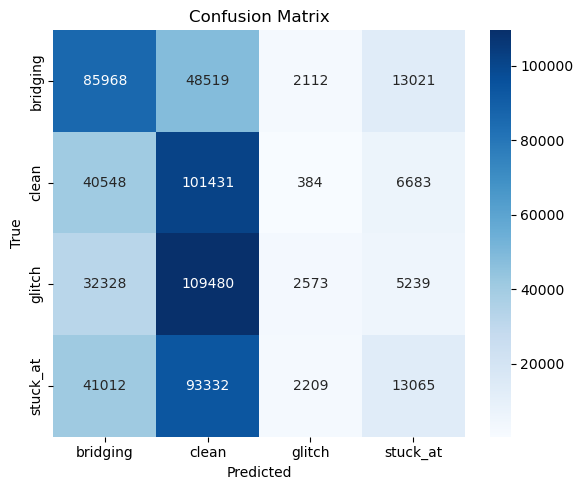

In [11]:
# eval_GAT.py (Jupyter-friendly version)

import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure model is in eval mode
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index)
        preds = out.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(data.y.cpu().numpy())

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print ('Confusion Matrix: \n',cm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


#### Some modifications to improve accuracy. 

In [16]:
# ==== train_GAT.py (Jupyter-friendly; leaves `model` in memory) ====
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
from dgl.nn import GATConv
from sklearn.model_selection import train_test_split
from collections import Counter

# --------------- config ---------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NODES_CSV = "nodes_enhanced.csv"
EDGES_CSV = "edges_enhanced.csv"
EPOCHS = 40
NEG_RATIO = 3          # clean:positive sampling ratio per graph during training
MIN_NEG_PER_GRAPH = 200
MAX_NEG_PER_GRAPH = 10000
LR = 3e-3
WEIGHT_DECAY = 5e-4
DROPOUT = 0.3
HID = 64
HEADS = (4, 4)
LABEL_SMOOTH = 0.05    # small smoothing helps stability on long-tail

torch.manual_seed(42)
np.random.seed(42)

# --------------- load data ---------------
nodes_df = pd.read_csv(NODES_CSV)
edges_df = pd.read_csv(EDGES_CSV)

desired_classes = ['clean', 'stuck_at', 'glitch', 'bridging']
classes = [c for c in desired_classes if c in nodes_df['fault_type'].unique().tolist()]
cls2idx = {c:i for i,c in enumerate(classes)}
num_classes = len(classes)
print("Classes:", classes)

# features: gate one-hot + numeric
all_gate_types = sorted(nodes_df['gate_type'].unique().tolist())
gate2idx = {g:i for i,g in enumerate(all_gate_types)}
GATE_OH = len(all_gate_types)

candidate_num = [
    'total_degree','path_depth','CC0_exact','CC1_exact','CO_exact',
    'dist_to_PO','fanout_norm','gate_delay',
    'is_in_fanout_domain','is_on_failure_path','num_paths_through'
]
num_cols = [c for c in candidate_num if c in nodes_df.columns]
if not num_cols:
    num_cols = ['total_degree','path_depth','CC0','CC1','CO']
print("Gate types:", all_gate_types)
print("Numeric node features used:", num_cols)

# --------------- split by netlist file ---------------
netlists = sorted(nodes_df['netlist_file'].unique().tolist())
train_nets, test_nets = train_test_split(netlists, test_size=0.2, random_state=42)
print(f"Train nets: {len(train_nets)} | Test nets: {len(test_nets)}")

# normalization stats on training nodes only
train_mask_df = nodes_df['netlist_file'].isin(train_nets)
train_nums = nodes_df.loc[train_mask_df, num_cols].astype(np.float32).values
means = train_nums.mean(axis=0)
stds = train_nums.std(axis=0) + 1e-6

def build_graph_for_group(group_nodes, sub_edges, ftype):
    """
    Build DGLGraph for a (netlist_file, fault_type) group.
    - indices come from group_nodes row ordering
    - edges mapped through node_id -> local index
    - features = one-hot(gate_type) + standardized numeric
    - labels: clean graph ? all clean; else faulty nodes(label==1) ? fault_type, others ? clean
    """
    node_ids = group_nodes['node_id'].tolist()
    id2idx = {nid:i for i,nid in enumerate(node_ids)}
    N = len(node_ids)

    # map edges
    src_idx, dst_idx = [], []
    for _, e in sub_edges.iterrows():
        s, d = e['src_node'], e['dst_node']
        if s in id2idx and d in id2idx:
            src_idx.append(id2idx[s]); dst_idx.append(id2idx[d])
    if len(src_idx) == 0:
        g = dgl.graph(([], []), num_nodes=N)
    else:
        g = dgl.graph((src_idx, dst_idx), num_nodes=N)

    # features
    oh = np.zeros((N, GATE_OH), dtype=np.float32)
    for i,gt in enumerate(group_nodes['gate_type'].tolist()):
        j = gate2idx.get(gt, None)
        if j is not None:
            oh[i, j] = 1.0
    nums = group_nodes[num_cols].astype(np.float32).values
    nums = (nums - means) / stds
    x = np.concatenate([oh, nums], axis=1)

    # labels
    y = np.zeros(N, dtype=np.int64)
    clean_idx = cls2idx['clean']
    if ftype == 'clean':
        y[:] = clean_idx
    else:
        fault_mask = group_nodes['label'].astype(int).values if 'label' in group_nodes.columns else np.zeros(N, dtype=int)
        y = np.where(fault_mask==1, cls2idx[ftype], clean_idx).astype(np.int64)

    g.ndata['x'] = torch.from_numpy(x)
    g.ndata['y'] = torch.from_numpy(y)
    g = dgl.add_self_loop(g)
    return g

# build graphs
graphs, meta = [], []
for (netlist_file, fault_type), group_nodes in nodes_df.groupby(['netlist_file','fault_type'], sort=False):
    if fault_type not in cls2idx:
        continue
    edges_sub = edges_df[(edges_df.netlist_file==netlist_file) & (edges_df.fault_type==fault_type)]
    g = build_graph_for_group(group_nodes, edges_sub, fault_type)
    graphs.append(g)
    meta.append((netlist_file, fault_type))

print(f"Built {len(graphs)} graphs (netlist_file x fault_type).")
in_dim = graphs[0].ndata['x'].shape[1]
print("Input feature dim:", in_dim)

train_graphs = [g for (g,(nf,ft)) in zip(graphs, meta) if nf in train_nets]
test_graphs  = [g for (g,(nf,ft)) in zip(graphs, meta) if nf in test_nets]
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# ---------------- class weights (from training nodes) ----------------
y_train_all = torch.cat([g.ndata['y'] for g in train_graphs], dim=0)
counts = torch.bincount(y_train_all, minlength=num_classes).float()
counts[counts==0] = counts[counts>0].min()
weights = (counts.sum() / counts)
weights = weights / weights.mean()
print("Class weights:", weights.tolist())

# ---------------- sampling masks for imbalance ----------------
clean_idx = cls2idx['clean']
def sample_train_mask(g, neg_ratio=NEG_RATIO):
    """
    Build a boolean mask: all positives + sampled negatives.
    - If graph is 'clean only', sample a fixed number of clean nodes.
    """
    y = g.ndata['y']
    pos_mask = (y != clean_idx)
    pos_idx = pos_mask.nonzero(as_tuple=False).flatten()
    neg_idx = (y == clean_idx).nonzero(as_tuple=False).flatten()

    if pos_idx.numel() == 0:
        # purely clean graph -> sample a small fixed subset to help decision boundary
        k = min(MAX_NEG_PER_GRAPH, max(MIN_NEG_PER_GRAPH, int(0.05 * max(1, y.numel()))))
        if neg_idx.numel() > k:
            perm = torch.randperm(neg_idx.numel())[:k]
            neg_idx = neg_idx[perm]
        mask_idx = neg_idx
    else:
        k = min(neg_ratio * pos_idx.numel(), MAX_NEG_PER_GRAPH)
        k = max(k, MIN_NEG_PER_GRAPH)
        if neg_idx.numel() > k:
            perm = torch.randperm(neg_idx.numel())[:k]
            neg_idx = neg_idx[perm]
        mask_idx = torch.cat([pos_idx, neg_idx], dim=0)

    mask = torch.zeros_like(y, dtype=torch.bool)
    mask[mask_idx] = True
    return mask

# ---------------- model ----------------
class NodeGAT(nn.Module):
    def __init__(self, in_dim, hid=64, num_classes=4, heads=(4,4), dropout=0.3, label_smooth=0.0):
        super().__init__()
        self.gat1 = GATConv(in_dim, hid, heads[0], feat_drop=dropout, attn_drop=dropout, activation=nn.ELU())
        self.gat2 = GATConv(hid*heads[0], hid, heads[1], feat_drop=dropout, attn_drop=dropout, activation=None)
        # after gat2 we average heads -> (N, hid), so BN must be hid
        self.bn = nn.BatchNorm1d(hid)
        self.dropout = nn.Dropout(dropout)
        self.mlp = nn.Sequential(
            nn.Linear(hid, hid),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hid, num_classes)
        )
        self.label_smooth = label_smooth

    def forward(self, g):
        x = g.ndata['x'].to(self.gat1.fc.weight.device)
        h = self.gat1(g, x)          # (N, H1, hid)
        h = h.flatten(1)              # (N, H1*hid)
        h = self.dropout(h)
        h = self.gat2(g, h)          # (N, H2, hid)
        h = h.mean(1)                 # average heads -> (N, hid)
        h = self.bn(h)
        h = torch.relu(h)
        h = self.dropout(h)
        out = self.mlp(h)             # (N, num_classes)
        return out

model = NodeGAT(in_dim, hid=HID, num_classes=num_classes, heads=HEADS, dropout=DROPOUT, label_smooth=LABEL_SMOOTH).to(DEVICE)

# Label smoothing via CE (PyTorch >=1.10 supports label_smoothing)
crit = nn.CrossEntropyLoss(weight=weights.to(DEVICE), label_smoothing=LABEL_SMOOTH)
opt  = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ---------------- training / eval ----------------
@torch.no_grad()
def eval_split(graphs):
    model.eval()
    total_nodes, correct, loss_sum = 0, 0, 0.0
    for g in graphs:
        g = g.to(DEVICE)
        y = g.ndata['y']
        logits = model(g)
        loss = crit(logits, y)
        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total_nodes += y.numel()
        loss_sum += loss.item()
    return loss_sum / max(1, len(graphs)), correct / max(1, total_nodes)

def train_epoch(graphs):
    model.train()
    loss_sum = 0.0
    for g in graphs:
        g = g.to(DEVICE)
        y = g.ndata['y']
        mask = sample_train_mask(g)  # imbalance-aware sampling
        logits = model(g)
        loss = crit(logits[mask], y[mask])

        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        opt.step()

        loss_sum += loss.item()
    return loss_sum / max(1, len(graphs))

# quick sanity on sampled class balance
with torch.no_grad():
    tmp_cnt = Counter()
    for g in train_graphs[:10]:
        m = sample_train_mask(g)
        tmp_cnt.update(g.ndata['y'][m].tolist())
    print("Sampled class balance (first ~10 graphs):", {classes[i]: tmp_cnt.get(i,0) for i in range(num_classes)})

best_val = float('inf')
for ep in range(1, EPOCHS+1):
    tr_loss = train_epoch(train_graphs)
    val_loss, val_acc = eval_split(test_graphs)
    if ep % 5 == 0 or ep == 1:
        print(f"[Epoch {ep:02d}] train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")
    if val_loss < best_val:
        best_val = val_loss

print("Training complete. `model` is ready in memory for evaluation.")


Classes: ['clean', 'stuck_at', 'glitch', 'bridging']
Gate types: ['and', 'bridge', 'glitch', 'nand', 'nor', 'not', 'or', 'sa0', 'sa1', 'xor']
Numeric node features used: ['total_degree', 'path_depth', 'CC0_exact', 'CC1_exact', 'CO_exact', 'dist_to_PO', 'fanout_norm', 'gate_delay']
Train nets: 24 | Test nets: 6
Built 120 graphs (netlist_file x fault_type).
Input feature dim: 18
Train graphs: 96 | Test graphs: 24
Class weights: [0.002278420375660062, 1.333422064781189, 1.332149863243103, 1.332149863243103]
Sampled class balance (first ~10 graphs): {'clean': 2739, 'stuck_at': 0, 'glitch': 0, 'bridging': 0}
[Epoch 01] train_loss=8.4576  val_loss=10.9864  val_acc=0.0017
[Epoch 05] train_loss=8.2873  val_loss=10.7381  val_acc=0.0013
[Epoch 10] train_loss=8.0254  val_loss=10.3912  val_acc=0.0014
[Epoch 15] train_loss=7.9408  val_loss=10.5309  val_acc=0.0017
[Epoch 20] train_loss=7.8813  val_loss=10.5299  val_acc=0.0023
[Epoch 25] train_loss=7.8618  val_loss=10.3101  val_acc=0.0021
[Epoch 30] 

In [17]:
import torch
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Ensure model is in evaluation mode
model.eval()

# Gather all predictions and labels
all_preds = []
all_labels = []

with torch.no_grad():
    for g in test_graphs:  # test_graphs from training cell
        g = g.to(DEVICE)
        logits = model(g)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = g.ndata["y"].cpu().numpy()
        
        all_preds.extend(preds)
        all_labels.extend(labels)

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Calculate metrics
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))



Test Accuracy: 0.0024

Classification Report:
              precision    recall  f1-score   support

       clean       0.00      0.00      0.00    483668
    stuck_at       0.01      0.01      0.01       687
      glitch       0.87      0.66      0.75       687
    bridging       0.00      1.00      0.00       687

    accuracy                           0.00    485729
   macro avg       0.22      0.42      0.19    485729
weighted avg       0.00      0.00      0.00    485729

Confusion Matrix:
[[     0   1091     64 482513]
 [     0      7      2    678]
 [     0      0    452    235]
 [     0      0      0    687]]


/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f

#### Another Modifications

In [25]:
# --- train_GAT_relational.py (Cell 1) ---
import math
from collections import defaultdict, deque
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# -------------------------
# Config
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"
EPOCHS = 50
LR = 7e-4
BATCH_SIZE = 1
DROPOUT = 0.4
HID = 64
HEADS1 = 4
HEADS2 = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -------------------------
# Load CSVs
# -------------------------
nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

# sanity
need_node_cols = [
    "netlist_file","fault_type","node_id","gate_type","label",
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]
for c in need_node_cols:
    if c not in nodes_df.columns:
        raise SystemExit(f"Missing column in nodes CSV: {c}")

need_edge_cols = ["netlist_file","fault_type","src_node","dst_node"]
for c in need_edge_cols:
    if c not in edges_df.columns:
        raise SystemExit(f"Missing column in edges CSV: {c}")

# -------------------------
# Encode class labels
# -------------------------
le = LabelEncoder()
nodes_df["cls"] = le.fit_transform(nodes_df["fault_type"])
class_names = list(le.classes_)
num_classes = len(class_names)
print("Classes:", class_names)

# -------------------------
# Gate type one-hot (logic only)
# -------------------------
logic_gate_whitelist = {"and","nand","nor","not","or","xor","buf","pi","po","PI","PO"}
gate_norm = nodes_df["gate_type"].astype(str).str.lower()
gate_norm = gate_norm.where(gate_norm.isin(logic_gate_whitelist), other="other")
gate_vocab = sorted(gate_norm.unique().tolist())
g2i = {g:i for i,g in enumerate(gate_vocab)}
nodes_df["gate_oh_idx"] = gate_norm.map(g2i)
G = len(gate_vocab)
print("Gate vocab:", gate_vocab)

# -------------------------
# Base numeric features
# -------------------------
base_num_cols = [
    "total_degree","path_depth","CC0_exact","CC1_exact","CO_exact",
    "dist_to_PO","fanout_norm","gate_delay"
]

# -------------------------
# Split by netlist
# -------------------------
netlists = nodes_df["netlist_file"].drop_duplicates().values
train_nets, test_nets = train_test_split(netlists, test_size=0.2, random_state=42, shuffle=True)
print(f"Train nets: {len(train_nets)} | Test nets: {len(test_nets)}")

# -------------------------
# Helper to build JOINT graph per netlist_file
# - Edges: take from the CLEAN variant if available; else union across types
# - Labels: start as CLEAN; for each non-clean type, nodes with label==1 -> set to that fault class
# -------------------------
def build_joint_graphs(nets):
    graphs = []
    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf]
        if nd_sub.empty:
            continue

        # node ordering by node_id for deterministic mapping
        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid:i for i,nid in enumerate(node_ids)}
        N = len(node_ids)

        # choose edges: prefer CLEAN
        clean_edges = edges_df[(edges_df["netlist_file"]==nf) & (edges_df["fault_type"]=="clean")]
        if not clean_edges.empty:
            ee = clean_edges
        else:
            # fallback: union over all fault types (dedup)
            ee = edges_df[edges_df["netlist_file"]==nf][["src_node","dst_node"]].drop_duplicates()

        src, dst = [], []
        for _, r in ee.iterrows():
            s, d = r["src_node"], r["dst_node"]
            if s in id2idx and d in id2idx:
                src.append(id2idx[s]); dst.append(id2idx[d])
        edge_index = torch.tensor([src, dst], dtype=torch.long) if len(src) else torch.empty((2,0), dtype=torch.long)

        # gate one-hot
        # use the gate type from CLEAN if present, else first occurrence per node
        gt_map = {}
        clean_nodes = nd_sub[nd_sub["fault_type"]=="clean"]
        if not clean_nodes.empty:
            for _, r in clean_nodes.iterrows():
                gt_map[r["node_id"]] = r["gate_type"]
        else:
            # first appear for each node
            first = nd_sub.sort_values("fault_type").drop_duplicates("node_id", keep="first")
            gt_map = dict(zip(first["node_id"], first["gate_type"]))

        gate_oh = np.zeros((N, G), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            gname = str(gt_map.get(nid, "other")).lower()
            gname = gname if gname in g2i else "other"
            gate_oh[i, g2i[gname]] = 1.0

        # numeric base features (from CLEAN rows if available; else mean over types for that node)
        # Build per-node numeric vector
        nums = np.zeros((N, len(base_num_cols)), dtype=np.float32)
        for i, nid in enumerate(node_ids):
            rows = nd_sub[nd_sub["node_id"]==nid]
            row = rows[rows["fault_type"]=="clean"]
            if row.empty:
                row = rows.iloc[[0]]
            nums[i,:] = row[base_num_cols].astype(np.float32).values[0]

        # JOINT labels:
        # Start as CLEAN, then overlay faults where nodes have label==1 for that fault type.
        y = np.full(N, fill_value=class_names.index("clean") if "clean" in class_names else 0, dtype=np.int64)
        for ft in class_names:
            if ft == "clean":
                continue
            sub = nd_sub[nd_sub["fault_type"]==ft]
            if sub.empty: 
                continue
            # label==1 indicates the faulty node(s)
            faulty_nodes = sub[sub["label"]==1]["node_id"].values
            for nid in faulty_nodes:
                if nid in id2idx:
                    y[id2idx[nid]] = class_names.index(ft)

        data = Data(
            x=torch.from_numpy(np.concatenate([gate_oh, nums], axis=1)),
            edge_index=edge_index,
            y=torch.from_numpy(y),
        )
        data.netlist_file = nf
        graphs.append(data)
    return graphs

train_graphs = build_joint_graphs(train_nets)
test_graphs  = build_joint_graphs(test_nets)
print(f"Built {len(train_graphs)} train + {len(test_graphs)} test joint graphs.")

# -------------------------
# Build relational features on the fly
#   - neighbor means of CCs and deltas
#   - k-hop (1..3) in/out unique counts
#   - #PI ancestors (<=3 hops), #PO descendants (<=3 hops)
#   Well append these to x.
# -------------------------
# Locate indices of CC features inside current x
# current x = [onehot G] + base_num_cols in order:
# idx map for numeric slice:
num_start = G
idx_CC0 = num_start + base_num_cols.index("CC0_exact")
idx_CC1 = num_start + base_num_cols.index("CC1_exact")
idx_CO  = num_start + base_num_cols.index("CO_exact")
idx_path = num_start + base_num_cols.index("path_depth")
idx_distPO = num_start + base_num_cols.index("dist_to_PO")

def build_adj_lists(edge_index, N):
    src = edge_index[0].cpu().numpy().tolist() if edge_index.numel() else []
    dst = edge_index[1].cpu().numpy().tolist() if edge_index.numel() else []
    out_adj = [[] for _ in range(N)]
    in_adj  = [[] for _ in range(N)]
    for s,d in zip(src,dst):
        out_adj[s].append(d)
        in_adj[d].append(s)
    return in_adj, out_adj

def k_hop_unique_counts(start_nodes, adj, K=3):
    """Return array counts of unique nodes reachable from each node within <=K hops."""
    N = len(adj)
    out = np.zeros(N, dtype=np.int32)
    for u in range(N):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen and w != u:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier:
                break
        out[u] = len(seen)
    return out

def neighbor_mean(arr, adj):
    """Mean of neighbors' arr for each node; if no neighbors, use self value."""
    N = len(adj)
    out = np.zeros(N, dtype=np.float32)
    for u in range(N):
        neigh = adj[u]
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])
    return out

def append_relational_features(data: Data):
    x = data.x.clone().float()
    N = x.size(0)
    in_adj, out_adj = build_adj_lists(data.edge_index, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co  = x[:, idx_CO ].cpu().numpy()

    # neighbor means (predecessors & successors)
    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean  = neighbor_mean(co,  in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean  = neighbor_mean(co,  out_adj)

    # deltas
    cc0_in_delta  = cc0 - cc0_in_mean
    cc1_in_delta  = cc1 - cc1_in_mean
    co_in_delta   = co  - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta  = co  - co_out_mean

    # k-hop counts (approx cone sizes)
    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.int32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.int32)
    in_k2 = k_hop_unique_counts(range(N), in_adj, K=2)
    out_k2 = k_hop_unique_counts(range(N), out_adj, K=2)
    in_k3 = k_hop_unique_counts(range(N), in_adj, K=3)
    out_k3 = k_hop_unique_counts(range(N), out_adj, K=3)

    # PI/PO detection from original features:
    # treat nodes with small path_depth as PI-ish; small dist_to_PO as PO-ish
    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()
    # Heuristics: PI if path_depth == min in graph; PO if dist_to_PO == 0
    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    # counts within 3 hops
    def count_reach(u, targets, adj, K=3):
        seen = set()
        frontier = [u]
        for _ in range(K):
            nxt = []
            for v in frontier:
                for w in adj[v]:
                    if w not in seen:
                        seen.add(w)
                        nxt.append(w)
            frontier = nxt
            if not frontier:
                break
        return sum(1 for w in seen if w in targets)

    pi_anc3 = np.zeros(N, dtype=np.int32)
    po_des3 = np.zeros(N, dtype=np.int32)
    for u in range(N):
        pi_anc3[u] = count_reach(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reach(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean,  cc1_in_mean,  co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta,cc1_out_delta,co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)
    return data

# Append relational features to all graphs
for lst in (train_graphs, test_graphs):
    for i in range(len(lst)):
        lst[i] = append_relational_features(lst[i])

# -------------------------
# Normalize ALL numeric columns from TRAIN only
# current x = [onehot G] + base_num + relational (20)
# -> normalize the numeric (everything except onehot G)
# -------------------------
num_slice_start = G
num_dim = train_graphs[0].x.size(1) - G

def fit_norm(graphs):
    X = torch.cat([g.x[:, num_slice_start:] for g in graphs], dim=0).float().cpu().numpy()
    mean = X.mean(axis=0); std = X.std(axis=0) + 1e-6
    return mean.astype(np.float32), std.astype(np.float32)

mu, sigma = fit_norm(train_graphs)

def apply_norm(graphs, mu, sigma):
    for g in graphs:
        nums = g.x[:, num_slice_start:].float().cpu().numpy()
        nums = (nums - mu) / sigma
        g.x[:, num_slice_start:] = torch.from_numpy(nums).float()
    return graphs

train_graphs = apply_norm(train_graphs, mu, sigma)
test_graphs  = apply_norm(test_graphs,  mu, sigma)

print("Final input dim:", train_graphs[0].x.size(1))
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# -------------------------
# Model
# -------------------------
class NodeGAT(nn.Module):
    def __init__(self, in_dim, hid=64, out_dim=4, heads1=4, heads2=4, dropout=0.4):
        super().__init__()
        self.gat1 = GATConv(in_dim, hid, heads=heads1, dropout=dropout, concat=True)
        self.gat2 = GATConv(hid*heads1, hid, heads=heads2, dropout=dropout, concat=False)
        self.ln1 = nn.LayerNorm(hid*heads1)
        self.ln2 = nn.LayerNorm(hid)
        self.res1 = nn.Linear(in_dim, hid*heads1)
        self.res2 = nn.Linear(hid*heads1, hid)
        self.dropout = nn.Dropout(dropout)
        self.cls = nn.Linear(hid, out_dim)

    def forward(self, data):
        x, ei = data.x, data.edge_index
        h1 = self.gat1(x, ei)
        h1 = self.ln1(h1 + self.res1(x))
        h1 = F.elu(h1)
        h1 = self.dropout(h1)

        h2 = self.gat2(h1, ei)
        h2 = self.ln2(h2 + self.res2(h1))
        h2 = F.elu(h2)
        h2 = self.dropout(h2)

        return self.cls(h2)

in_dim = train_graphs[0].x.size(1)
model = NodeGAT(in_dim=in_dim, hid=HID, out_dim=num_classes,
                heads1=HEADS1, heads2=HEADS2, dropout=DROPOUT).to(DEVICE)

# -------------------------
# Loss & Optimizer
#   - global class weights (train only)
#   - balanced per-graph sampling for node loss
# -------------------------
train_labels_all = np.concatenate([g.y.numpy() for g in train_graphs], axis=0)
cls_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)
w = (cls_counts.max() / (cls_counts + 1e-6))
w = w / w.sum() * num_classes
weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
print("Class weights:", weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=5e-4)

rng = np.random.default_rng(12345)

def sample_balanced_idx(y, max_per_fault=512, clean_ratio=1.0):
    y_np = y.cpu().numpy()
    # 'clean' class index:
    clean_idx = class_names.index("clean") if "clean" in class_names else int(pd.Series(y_np).value_counts().idxmax())

    idxs = []
    fault_total = 0
    for c in range(num_classes):
        if c == clean_idx: 
            continue
        c_idx = np.where(y_np == c)[0]
        if len(c_idx) == 0: 
            continue
        k = min(len(c_idx), max_per_fault)
        sel = rng.choice(c_idx, size=k, replace=False)
        idxs.append(sel)
        fault_total += k

    if fault_total > 0:
        c_idx = np.where(y_np == clean_idx)[0]
        if len(c_idx) > 0:
            k_clean = min(len(c_idx), int(math.ceil(clean_ratio * fault_total)))
            selc = rng.choice(c_idx, size=k_clean, replace=False)
            idxs.append(selc)

    if not idxs:
        sel = rng.choice(np.arange(len(y_np)), size=min(256, len(y_np)), replace=False)
        return torch.from_numpy(np.sort(sel)).long().to(DEVICE)
    return torch.from_numpy(np.unique(np.concatenate(idxs))).long().to(DEVICE)

def train_epoch(graphs):
    model.train()
    loader = DataLoader(graphs, batch_size=1, shuffle=True)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        sel = sample_balanced_idx(data.y, max_per_fault=512, clean_ratio=1.0)
        loss = criterion(logits[sel], data.y[sel])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tot_loss += loss.item() * sel.numel()
        tot_nodes += sel.numel()

        with torch.no_grad():
            pred = logits[sel].argmax(dim=1)
            corr += int((pred == data.y[sel]).sum().item())
            seen += int(sel.numel())
    return tot_loss/max(1,tot_nodes), corr/max(1,seen)

@torch.no_grad()
def eval_epoch(graphs):
    model.eval()
    loader = DataLoader(graphs, batch_size=1, shuffle=False)
    tot_loss, tot_nodes, corr, seen = 0.0, 0, 0, 0
    for data in loader:
        data = data.to(DEVICE)
        logits = model(data)
        loss = criterion(logits, data.y)
        tot_loss += loss.item() * data.num_nodes
        tot_nodes += data.num_nodes
        pred = logits.argmax(dim=1)
        corr += int((pred == data.y).sum().item())
        seen += int(data.num_nodes)
    return tot_loss/max(1,tot_nodes), corr/max(1,seen)

best_val = float('inf')
for ep in range(1, EPOCHS+1):
    tr_loss, tr_acc = train_epoch(train_graphs)
    va_loss, va_acc = eval_epoch(test_graphs)
    if ep % 5 == 0 or ep == 1:
        print(f"[Epoch {ep:02d}] train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    if va_loss < best_val:
        best_val = va_loss
        best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}

if 'best_state' in locals():
    model.load_state_dict(best_state)

print("Training done. `model`, `class_names`, `test_graphs`, `DEVICE` are ready.")


Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Gate vocab: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Train nets: 24 | Test nets: 6
Built 24 train + 6 test joint graphs.
Final input dim: 35
Train graphs: 24 | Test graphs: 6
Class weights: [1.3747077  0.00848948 1.3747077  1.2420951 ]
[Epoch 01] train_loss=0.7636 train_acc=0.4181 val_loss=2.0360 val_acc=0.1370
[Epoch 05] train_loss=0.2813 train_acc=0.8290 val_loss=0.8351 val_acc=0.8734
[Epoch 10] train_loss=0.2753 train_acc=0.9204 val_loss=0.6805 val_acc=0.9660
[Epoch 15] train_loss=0.2268 train_acc=0.9449 val_loss=0.5545 val_acc=0.9775
[Epoch 20] train_loss=0.2081 train_acc=0.9490 val_loss=0.5357 val_acc=0.9802
[Epoch 25] train_loss=0.2220 train_acc=0.9489 val_loss=0.2683 val_acc=0.9852
[Epoch 30] train_loss=0.1887 train_acc=0.9544 val_loss=0.2309 val_acc=0.9880
[Epoch 35] train_loss=0.2006 train_acc=0.9553 val_loss=0.3922 val_acc=0.9891
[Epoch 40] train_loss=0.1897 train_acc=0.9587 val_loss=0.1669 val_acc=0.

Test Accuracy: 0.9930

Classification Report:
              precision    recall  f1-score   support

    bridging     0.9977    0.9735    0.9854       452
       clean     1.0000    0.9932    0.9966    120917
      glitch     0.9068    0.9469    0.9264       452
    stuck_at     0.4589    0.9985    0.6288       687

    accuracy                         0.9930    122508
   macro avg     0.8408    0.9780    0.8843    122508
weighted avg     0.9966    0.9930    0.9942    122508


Confusion Matrix:
 [[   440      0      9      3]
 [     0 120100     35    782]
 [     0      0    428     24]
 [     1      0      0    686]]


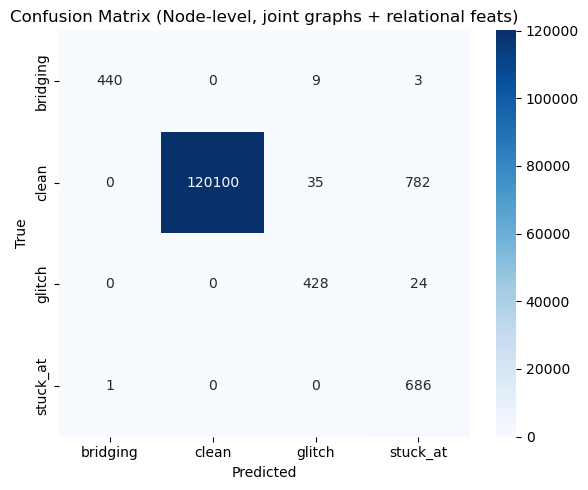

In [26]:
# --- eval_GAT_relational.py (Cell 2) ---
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader

model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for data in DataLoader(test_graphs, batch_size=1, shuffle=False):
        data = data.to(DEVICE)
        logits = model(data)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(data.y.cpu().numpy().tolist())

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Node-level, joint graphs + relational feats)")
plt.tight_layout()
plt.show()
